## Импорт библиотек

In [144]:
# ! pip install pandas numpy matplotlib scikit-learn scipy cartopy geopy shapely

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from geopy.distance import geodesic
from geopy import Point
import cartopy.crs as ccrs
from shapely.geometry import LineString, Point as ShapelyPoint, Polygon
from shapely.ops import substring

pd.set_option('display.max_columns', None)

## Исходные данные и параметры

In [146]:
# Insert here your seismic source parameters [globalcmt.org]
# 2021 Chignik earthquake

earthquake = {
    'event': '2021 Chignik earthquake',
    'latitude': 55.40,
    'longitude': -157.32,
    'depth_km': 29.6,
    'Mw': 8.2,
    'scalar_moment_Nm': 2.84e28,  # скалярный момент в Н * м
    'strike_deg': 238, # азимут
    'dip_deg': 10, # угол падения
    'rake_deg': 88 # разворот 
}

# Earthquake catalog data

earthquake_data_path = '../data/NEIC_Global.csv'

# Plate boundaries data

boundaries_data_path = '../data/All_boundaries'

# Filter out crustal earthquakes based on depth and distance from trench

min_crustal_depth = -35  # events deeper than -35 km (e.g. -40, -50) are not considered crustal
min_trench_distance = 200  # minimum distance from trench in km

# Filter initial seismic catalog to get earthquakes with magnitudes exceed threshold

mag_threshold = 0

unreliable_depths = [-33, -35]

# Piecewise linear approximation segment length

segment_length = 30  # km

## Определение параметров очага землетрясения

In [147]:
# Calculating size of rupture using Riznichenko formulae

earthquake['length'] = 10 ** ( 0.440*earthquake['Mw'] -1.289 )
earthquake['width'] = 10 ** ( 0.401*earthquake['Mw'] -1.448 )

print(f"{earthquake['event']} located at ({earthquake['latitude']}°N, {earthquake['longitude']}°E),\n"
      f"Mw={earthquake['Mw']}, depth={earthquake['depth_km']} km, source length={earthquake['length']} km, source_width={earthquake['width']} km")

2021 Chignik earthquake located at (55.4°N, -157.32°E),
Mw=8.2, depth=29.6 km, source length=208.44908830972886 km, source_width=69.2149644226647 km


## Подготовка сейсмических данных

In [148]:
# Load the uploaded CSV file
df = pd.read_csv(earthquake_data_path)

# Remove duplicates
df_cleaned = df.drop_duplicates(subset=df.columns[:5], keep='first').reset_index(drop=True)

# Print summary
print("=" * 50)
print("REMOVE DUPLICATES")
print("-" * 50)
print(f"Original number of rows:            {len(df):>12,}")
print(f"Rows after removing duplicates:     {len(df_cleaned):>12,}")
print(f"Removed duplicate rows:             {len(df) - len(df_cleaned):>12,}")
print("=" * 50)
print(f"Minimum magnitude:                  {df_cleaned.mag.min():>12.2f}")
print(f"Maximum magnitude:                  {df_cleaned.mag.max():>12.2f}")

df = df_cleaned

# Select only the required columns
final_df = df[['latitude', 'longitude', 'depth', 'mag']]

# Filter initial seismic catalog to get earthquakes with magnitudes exceed threshold
print("=" * 50)
print("MAGNITUDE FILTERING")
print("-" * 50)
print(f"Magnitude threshold:                {mag_threshold:>12.2f}")
print(f"Rows before magnitude filtering:    {len(final_df):>12,}")

final_df = final_df[final_df['mag'] > mag_threshold]

print(f"Rows after magnitude filtering:     {len(final_df):>12,}")
print(f"Removed low magnitude events:       {len(df) - len(final_df):>12,}")
print("-" * 50)
print(f"Minimum magnitude (filtered):       {final_df.mag.min():>12.2f}")

# Cleaning data from NaNs
print("=" * 50)
print("REMOVE MISSING VALUES")
print("-" * 50)
print(f"Rows before removing NaNs:          {len(final_df):>12,}")

final_df_clean = final_df.dropna().reset_index(drop=True, inplace=False)

print(f"Rows after removing NaNs:           {len(final_df_clean):>12,}")
print(f"Removed rows with NaNs:             {len(final_df) - len(final_df_clean):>12,}")

REMOVE DUPLICATES
--------------------------------------------------
Original number of rows:                 286,453
Rows after removing duplicates:          286,452
Removed duplicate rows:                        1
Minimum magnitude:                          3.38
Maximum magnitude:                          9.50
MAGNITUDE FILTERING
--------------------------------------------------
Magnitude threshold:                        0.00
Rows before magnitude filtering:         286,452
Rows after magnitude filtering:          286,452
Removed low magnitude events:                  0
--------------------------------------------------
Minimum magnitude (filtered):               3.38
REMOVE MISSING VALUES
--------------------------------------------------
Rows before removing NaNs:               286,452
Rows after removing NaNs:                285,780
Removed rows with NaNs:                      672


In [149]:
final_df_clean.head(3)

,latitude,longitude,depth,mag
0,48.0,146.0,450.0,7.50
1,38.7,141.1,5.0,7.00
2,57.4,-151.0,20.0,7.86


## Загрузка границ литосферных плит

In [150]:
# Reading lithospheric plate bounadries for NNR-MORVEL56 model [Argus et al., 2011]

latitudes = []
longitudes = []

with open(boundaries_data_path, 'r') as file:
    for line in file:
        if not line.startswith(' '):
            continue  # skip comment lines without leading spaces
        try:
            parts = line.strip().split()
            if len(parts) != 2:
                print(f"Skipping malformed line: {line.strip()}")
                continue
            lat, lon = map(float, parts)
            latitudes.append(lat)
            longitudes.append(lon)
        except Exception as e:
            print(f"Error parsing line '{line.strip()}': {e}")

boundaries_df = pd.DataFrame({
    'latitude': latitudes,
    'longitude': longitudes
})

boundaries_df.head()

,latitude,longitude
0,-54.852,-0.438
1,-54.677,-0.039
2,-54.451,0.443
3,-54.832,0.965
4,-54.399,1.695


## Построение геометрии поисковой области

In [151]:
# Calculating geographic area for catalog search
# Making boundary points in strike direction

# Half-length distance
half_length = earthquake['length'] / 2  # in km

# Starting point (epicenter)
epicenter = Point(earthquake['latitude'], earthquake['longitude'])

# Point in strike direction
point_forward = geodesic(kilometers=half_length).destination(epicenter, earthquake['strike_deg'])

# Point in opposite strike direction (+180°)
point_backward = geodesic(kilometers=half_length).destination(epicenter, (earthquake['strike_deg'] + 180) % 360)

print(f"Point forward (along strike): lat={point_forward.latitude}, lon={point_forward.longitude}")
print(f"Point backward (opposite strike): lat={point_backward.latitude}, lon={point_backward.longitude}")

Point forward (along strike): lat=54.896043640403725, lon=-158.69769240846855
Point backward (opposite strike): lat=55.88800233268656, lon=-155.90737245816666


## Визуализация геометрии поиска и отбор землетрясений в полигоне

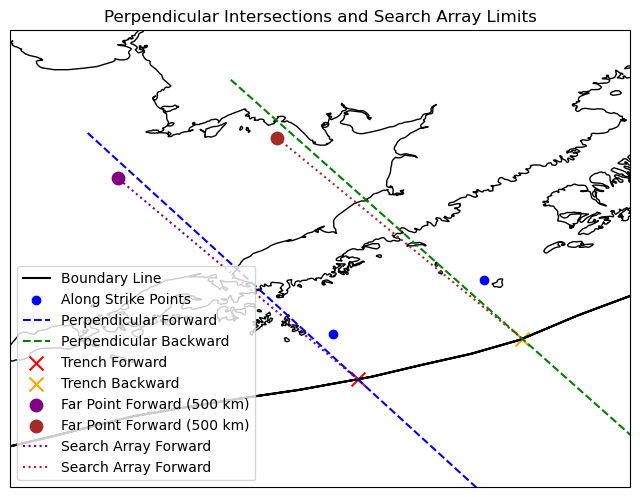

In [152]:
# Finding closest boundary(trench) and calculating intersect points

# Step 1: Boundary line from DataFrame
line = LineString(zip(boundaries_df['longitude'], boundaries_df['latitude']))

# -------- Perpendicular Line Construction ---------
def build_perpendicular_line(start_point, strike, length=500):
    az1 = (strike + 90) % 360
    az2 = (strike - 90) % 360
    p1 = geodesic(kilometers=length).destination(start_point, az1)
    p2 = geodesic(kilometers=length).destination(start_point, az2)
    return LineString([(p1.longitude, p1.latitude), (p2.longitude, p2.latitude)])

perp_line_forward = build_perpendicular_line(point_forward, earthquake['strike_deg'])
perp_line_backward = build_perpendicular_line(point_backward, earthquake['strike_deg'])

# -------- Intersection with boundary ---------
def project_intersection(perp_line, boundary_line):
    intersection = perp_line.intersection(boundary_line)
    if intersection.is_empty:
        return None, None
    if intersection.geom_type == 'Point':
        return intersection.y, intersection.x
    elif intersection.geom_type == 'MultiPoint':
        point = list(intersection)[0]
        return point.y, point.x
    else:
        return None, None

p1_lat, p1_lon = project_intersection(perp_line_forward, line)
p2_lat, p2_lon = project_intersection(perp_line_backward, line)

# Create Shapely Points for p1 and p2
p1_geom = ShapelyPoint(p1_lon, p1_lat)
p2_geom = ShapelyPoint(p2_lon, p2_lat)

# Project points onto the boundary line (returns distance along the line)
distance_p1 = line.project(p1_geom)
distance_p2 = line.project(p2_geom)

# Ensure proper order (from p1 to p2 along the boundary line)
start_distance = min(distance_p1, distance_p2)
end_distance = max(distance_p1, distance_p2)

# Extract the subsection of the boundary line (which is closest to the source)
sub_boundary = substring(line, start_distance, end_distance)

# Optional: Extract lat/lon coordinates
sub_lon, sub_lat = sub_boundary.xy

# -------- Compute far points 500 km from intersection ---------
def point_along_direction(lat, lon, azimuth, distance_km):
    start = Point(lat, lon)
    dest = geodesic(kilometers=distance_km).destination(start, azimuth)
    return dest.latitude, dest.longitude

def calculate_far_point(inter_lat, inter_lon, strike, direction):
    azimuth = (strike + 90) % 360 if direction == 'forward' else (strike - 90) % 360
    far_lat, far_lon = point_along_direction(inter_lat, inter_lon, azimuth, 500)
    return far_lat, far_lon

far1_lat, far1_lon = calculate_far_point(p1_lat, p1_lon, earthquake['strike_deg'], 'forward')
far2_lat, far2_lon = calculate_far_point(p2_lat, p2_lon, earthquake['strike_deg'], 'forward')

# -------- Plotting ---------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')

# Boundary line
ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

# Along-strike points
ax.scatter([point_forward.longitude, point_backward.longitude],
           [point_forward.latitude, point_backward.latitude], color='blue', label='Along Strike Points')

# Perpendicular lines
x_perp1, y_perp1 = perp_line_forward.xy
x_perp2, y_perp2 = perp_line_backward.xy
ax.plot(x_perp1, y_perp1, 'b--', label='Perpendicular Forward')
ax.plot(x_perp2, y_perp2, 'g--', label='Perpendicular Backward')

# Intersection points
ax.scatter(p1_lon, p1_lat, color='red', marker='x', s=100, label='Trench Forward')
ax.scatter(p2_lon, p2_lat, color='orange', marker='x', s=100, label='Trench Backward')

# Far points 500 km away
ax.scatter(far1_lon, far1_lat, color='purple', marker='o', s=80, label='Far Point Forward (500 km)')
ax.scatter(far2_lon, far2_lat, color='brown', marker='o', s=80, label='Far Point Forward (500 km)')

# Lines to far points
ax.plot([p1_lon, far1_lon], [p1_lat, far1_lat], 'purple', linestyle=':', label='Search Array Forward')
ax.plot([p2_lon, far2_lon], [p2_lat, far2_lat], 'brown', linestyle=':', label='Search Array Forward')

# Zoom to region
all_lats = [point_forward.latitude, point_backward.latitude, p1_lat, p2_lat, far1_lat, far2_lat]
all_lons = [point_forward.longitude, point_backward.longitude, p1_lon, p2_lon, far1_lon, far2_lon]
margin_lat, margin_lon = 2, 2
ax.set_extent([
    np.nanmin(all_lons) - margin_lon, np.nanmax(all_lons) + margin_lon,
    np.nanmin(all_lats) - margin_lat, np.nanmax(all_lats) + margin_lat
], crs=ccrs.PlateCarree())

ax.legend(loc='lower left')
ax.set_title('Perpendicular Intersections and Search Array Limits')
plt.show;

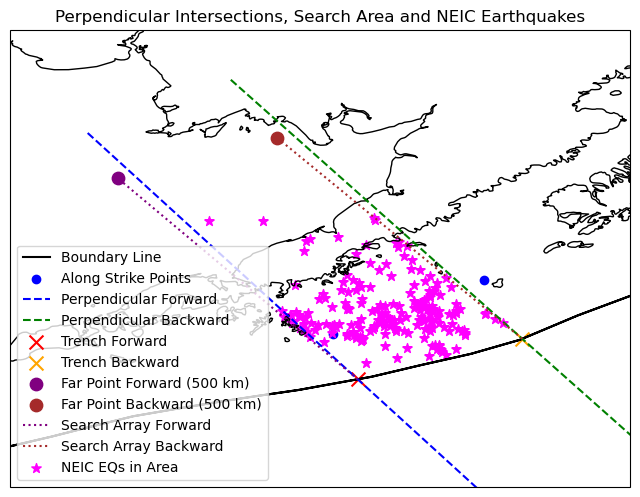

In [153]:
# -------- Define polygon for earthquake catalog search---------
search_polygon = Polygon([
    (p1_lon, p1_lat),
    (far1_lon, far1_lat),
    (far2_lon, far2_lat),
    (p2_lon, p2_lat),
    (p1_lon, p1_lat)
])

# Filter earthquakes inside the search polygon
def is_inside(lat, lon):
    return search_polygon.contains(ShapelyPoint(lon, lat))

final_df['inside_polygon'] = final_df.apply(lambda row: is_inside(row['latitude'], row['longitude']), axis=1)
selected_eq = final_df[final_df['inside_polygon']]

# -------- Plotting ---------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')

# Boundary line
ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

# Along-strike points
ax.scatter([point_forward.longitude, point_backward.longitude],
           [point_forward.latitude, point_backward.latitude], color='blue', label='Along Strike Points')

# Perpendicular lines
x_perp1, y_perp1 = perp_line_forward.xy
x_perp2, y_perp2 = perp_line_backward.xy
ax.plot(x_perp1, y_perp1, 'b--', label='Perpendicular Forward')
ax.plot(x_perp2, y_perp2, 'g--', label='Perpendicular Backward')

# Intersection points
ax.scatter(p1_lon, p1_lat, color='red', marker='x', s=100, label='Trench Forward')
ax.scatter(p2_lon, p2_lat, color='orange', marker='x', s=100, label='Trench Backward')

# Far points 500 km away
ax.scatter(far1_lon, far1_lat, color='purple', marker='o', s=80, label='Far Point Forward (500 km)')
ax.scatter(far2_lon, far2_lat, color='brown', marker='o', s=80, label='Far Point Backward (500 km)')

# Lines to far points
ax.plot([p1_lon, far1_lon], [p1_lat, far1_lat], 'purple', linestyle=':', label='Search Array Forward')
ax.plot([p2_lon, far2_lon], [p2_lat, far2_lat], 'brown', linestyle=':', label='Search Array Backward')

# Earthquakes inside polygon
ax.scatter(selected_eq['longitude'], selected_eq['latitude'], color='magenta', marker='*', s=50, label='NEIC EQs in Area')

# Zoom to region
all_lats = [point_forward.latitude, point_backward.latitude, p1_lat, p2_lat, far1_lat, far2_lat]
all_lons = [point_forward.longitude, point_backward.longitude, p1_lon, p2_lon, far1_lon, far2_lon]
margin_lat, margin_lon = 2, 2
ax.set_extent([
    np.nanmin(all_lons) - margin_lon, np.nanmax(all_lons) + margin_lon,
    np.nanmin(all_lats) - margin_lat, np.nanmax(all_lats) + margin_lat
], crs=ccrs.PlateCarree())

ax.legend(loc='lower left')
ax.set_title('Perpendicular Intersections, Search Area and NEIC Earthquakes')
plt.show()

## Расчет расстояний до желоба

In [154]:
# -------- Distance to Boundary Calculation ---------
def distance_to_boundary(lat, lon, boundary_line):
    point_geom = ShapelyPoint(lon, lat)
    nearest_point = boundary_line.interpolate(boundary_line.project(point_geom))
    distance = geodesic((lat, lon), (nearest_point.y, nearest_point.x)).km
    return distance

# DataFrame with depth and distance from boundary
depth_distance_df = selected_eq.copy()
depth_distance_df['depth'] = -np.abs(depth_distance_df['depth'])
depth_distance_df['distance'] = depth_distance_df.apply(
    lambda row: distance_to_boundary(row['latitude'], row['longitude'], sub_boundary), axis=1
)
depth_distance_df = depth_distance_df[['depth', 'distance', 'mag']]
depth_distance_df.reset_index(drop=True, inplace=True)

depth_distance_df.head()

,depth,distance,mag
0,-120.0,371.184246,6.50
1,-100.0,346.167871,6.75
2,-35.0,166.729606,5.96
3,-25.0,155.494015,7.00
4,-35.0,78.739439,6.23


In [155]:
depth_distance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   depth     193 non-null    float64
 1   distance  193 non-null    float64
 2   mag       193 non-null    float64
dtypes: float64(3)
memory usage: 4.7 KB


## Визуализация распределения землетрясений по глубине и расстоянию от желоба

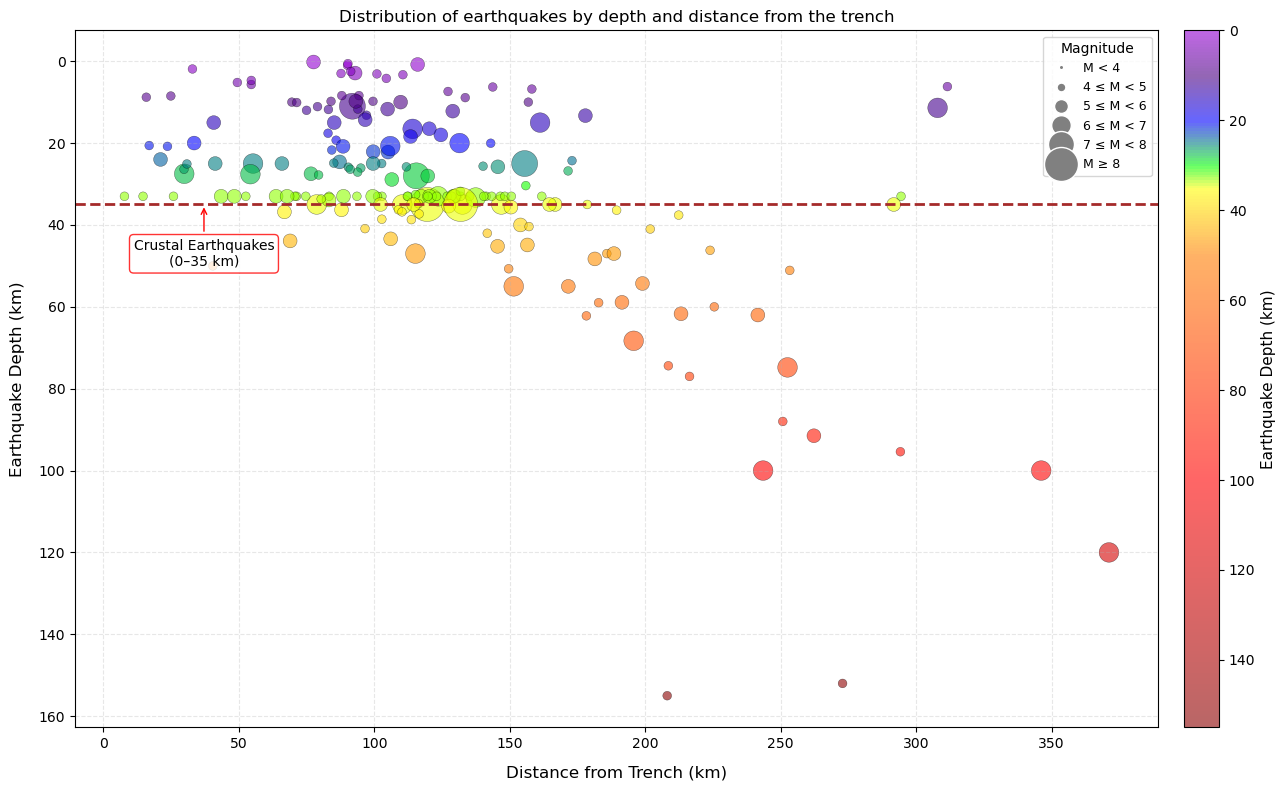

In [156]:
# Visualization of source data
 
max_depth = depth_distance_df['depth'].abs().max()

depth_segments = [
    (0.0, '#9400D3'), 
    (10/max_depth, '#4B0082'), 
    (20/max_depth, '#0000FF'), 
    (30/max_depth, '#00FF00'), 
    (35/max_depth, '#FFFF00'), 
    (50/max_depth, '#FF7F00'), 
    (100/max_depth if 100/max_depth <= 1.0 else 1.0, '#FF0000'), 
    (1.0, '#8B0000')
]

cmap_depth = LinearSegmentedColormap.from_list('depth_cmap', depth_segments)

plt.figure(figsize=(14, 8))

def mag_to_size(mag):
    if mag < 4:
        return 10
    elif 4 <= mag < 5:
        return 40
    elif 5 <= mag < 6:
        return 100
    elif 6 <= mag < 7:
        return 200
    elif 7 <= mag < 8:
        return 350
    else:
        return 600

sizes = depth_distance_df['mag'].apply(mag_to_size)

scatter = plt.scatter(
    depth_distance_df['distance'],
    -depth_distance_df['depth'],
    c=-depth_distance_df['depth'],
    s=sizes,
    cmap=cmap_depth,
    alpha=0.6,
    edgecolor='k',
    linewidth=0.3,
    vmin=0,
    vmax=max_depth
)

ax = plt.gca()
ax.invert_yaxis()
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')
plt.title('Distribution of earthquakes by depth and distance from the trench')
plt.xlabel('Distance from Trench (km)', fontsize=12, labelpad=10)
plt.ylabel('Earthquake Depth (km)', fontsize=12, labelpad=10)
plt.grid(alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Earthquake Depth (km)', fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.ax.invert_yaxis() 

# Magnitude legend

legend_labels = [
    ('M < 4', 3.5),
    ('4 ≤ M < 5', 4.5),
    ('5 ≤ M < 6', 5.5),
    ('6 ≤ M < 7', 6.5),
    ('7 ≤ M < 8', 7.5),
    ('M ≥ 8', 8.5)
]
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor='gray', markersize=np.sqrt(mag_to_size(mag)))
    for label, mag in legend_labels
]
plt.legend(handles=legend_elements, title='Magnitude', loc='upper right', frameon=True, fontsize=9)

# Inscription for crustal earthquakes
max_dist = depth_distance_df['distance'].max()
plt.annotate('Crustal Earthquakes\n(0–35 km)', 
             xy=(max_dist * 0.1, 35),
             xytext=(max_dist * 0.1, 50),
             arrowprops=dict(arrowstyle='->', color='red'),
             ha='center', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8),
             fontsize=10)

plt.tight_layout()

plt.savefig('plt/01_depth_distance.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show() 

##  Очистка данных от систематических ошибок глубин

In [157]:
# Define minimum repetition threshold for suspicious depths
min_repetitions = 10

# Count frequency of each depth value
depth_frequency = depth_distance_df['depth'].value_counts()

# Filter depths that appear more than threshold (likely erroneous measurements)
frequent_depths = depth_frequency[depth_frequency > min_repetitions]

print(f"Earthquake depths repeating more than {min_repetitions} times:")
print("-" * 50)
for depth, count in frequent_depths.items():
    print(f"Depth {depth:6.2f} km: {count:3d} repetitions")

# Remove unreliable depth measurements using the predefined list
depth_distance_df_cleaned = depth_distance_df[~depth_distance_df['depth'].isin(unreliable_depths)].copy()

X_raw = depth_distance_df_cleaned['distance'].values.reshape(-1, 1)
y_raw = depth_distance_df_cleaned['depth'].values

print("-" * 40)
print(f"Removed suspicious depths:    {len(depth_distance_df) - len(depth_distance_df_cleaned):>8,}")

# Pre-filtering of crustal earthquakes
def filter_crustal_earthquakes(distance, depth, max_shallow_depth, min_distance_for_filter):
    return ~((depth > max_shallow_depth) & (distance > min_distance_for_filter))

crustal_mask = filter_crustal_earthquakes(
    X_raw.flatten(), 
    y_raw, 
    max_shallow_depth=0, 
    min_distance_for_filter=0
)
X_filtered = X_raw[crustal_mask]
y_filtered = y_raw[crustal_mask]

print(f"\nCrustal earthquake filtering results:")
print("-" * 40)
print(f"Data points before filtering: {len(X_raw):>8,}")
print(f"Data points after filtering:  {len(X_filtered):>8,}")
print(f"Removed crustal earthquakes:  {len(X_raw) - len(X_filtered):>8,}")

Earthquake depths repeating more than 10 times:
--------------------------------------------------
Depth -33.00 km:  38 repetitions
Depth -35.00 km:  12 repetitions
----------------------------------------
Removed suspicious depths:          50

Crustal earthquake filtering results:
----------------------------------------
Data points before filtering:      143
Data points after filtering:       143
Removed crustal earthquakes:         0


## Построение робастной регрессии

Диапазон X_filtered: 15.8372564170096 371.1842456635109
Диапазон y_filtered: -155.0 -0.2
Среднее y_filtered: -31.512797202797202
Количество уникальных y_filtered: 119
Лучшие параметры: {'huberregressor__alpha': np.float64(0.021243911067827616), 'huberregressor__epsilon': np.float64(1.7272998688284025), 'huberregressor__max_iter': 500}


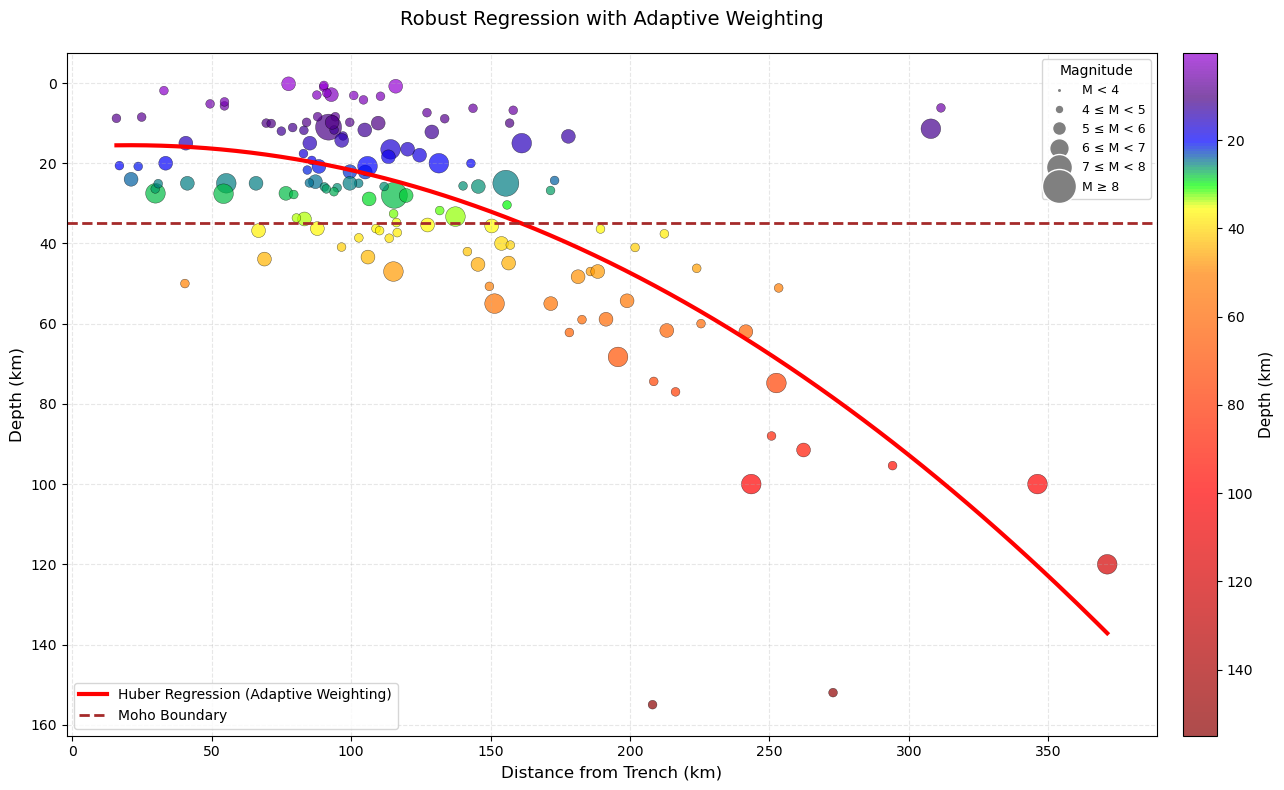

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.pipeline import make_pipeline
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# Параметры весов для Алеутской зоны субдукции
DISTANCE_THRESHOLD = 200.0    # ⬅️ Порог = 0 — все точки вне "порога", вес = HIGH_DISTANCE_WEIGHT
LOW_DISTANCE_WEIGHT = 2.0   # ⬅️ Не используется, но выставим в 1.0 для ясности
HIGH_DISTANCE_WEIGHT = 1.0  # ⬅️ Все точки получают вес 1.0
DEPTH_EXPONENT = 0.0        # ⬅️ Нулевая степень → (глубина / max_depth)^0 = 1 для всех

# 3. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
mu_X, sigma_X = scaler.mean_[0], scaler.scale_[0]
y_mean, y_std = y_filtered.mean(), y_filtered.std()
if y_std == 0:
    y_std = 1e-10  # Избегаем деления на ноль
y_scaled = (y_filtered - y_mean) / y_std

# Диагностика входных данных
print("Диапазон X_filtered:", X_filtered.min(), X_filtered.max())
print("Диапазон y_filtered:", y_filtered.min(), y_filtered.max())
print("Среднее y_filtered:", y_mean)
print("Количество уникальных y_filtered:", len(np.unique(y_filtered)))

# 4. Polynomial transform
degree = 2  # Полином 2-й степени (всегда)
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 5. Huber regression with adaptive weighting (IRLS-like)
# Начальная подгонка для вычисления начальных остатков
initial_model = LinearRegression()
initial_model.fit(X_poly, y_scaled)
y_pred_initial = initial_model.predict(X_poly)
residuals = np.abs(y_scaled - y_pred_initial)

# Адаптивные веса на основе остатков (весовая функция Хубера)
epsilon = 1.35  # Параметр Хубера
weights = np.where(residuals <= epsilon, 1.0, epsilon / residuals)
weights = np.nan_to_num(weights, nan=1.0, posinf=1.0, neginf=1.0)  # Замена NaN

# Синхронизация глубин
depths = depth_distance_df_cleaned.loc[crustal_mask, 'depth'].values  # Положительные глубины
assert len(depths) == len(y_filtered), "Несоответствие размеров depths и y_filtered"

# Проверка и очистка данных
if np.any(np.isnan(depths)) or np.any(np.isnan(y_filtered)):
    print("Обнаружены NaN в depths или y_filtered. Заменяем на 0.")
    depths = np.nan_to_num(depths, nan=0.0)
    y_filtered = np.nan_to_num(y_filtered, nan=0.0)

# Простые адаптивные веса (как изначально): по расстоянию и глубине
X_flat = X_filtered.flatten()
# Бинарный/простой вес по расстоянию (без градиентов)
distance_weights = np.where(X_flat > DISTANCE_THRESHOLD, HIGH_DISTANCE_WEIGHT, LOW_DISTANCE_WEIGHT)
distance_weights = np.nan_to_num(distance_weights, nan=LOW_DISTANCE_WEIGHT, posinf=LOW_DISTANCE_WEIGHT, neginf=LOW_DISTANCE_WEIGHT)

# Простое влияние глубины (степень для акцента на большие глубины)
max_depth = depths.max()
if max_depth == 0:
    max_depth = 1e-10  # Защита от деления на ноль
depth_influence = (np.abs(depths) / max_depth) ** DEPTH_EXPONENT
depth_influence = np.nan_to_num(depth_influence, nan=0.0, posinf=0.0, neginf=0.0)

# Комбинированные веса (для регионов можно задать разные параметры выше)
distance_depth_weights = distance_weights * depth_influence
combined_weights = weights * distance_depth_weights
combined_weights = np.nan_to_num(combined_weights, nan=1.0, posinf=1.0, neginf=1.0)

# Поиск оптимальных гиперпараметров
param_grid = {'huberregressor__epsilon': uniform(1.0, 4.0), 
              'huberregressor__alpha': uniform(0.00001, 0.1), 
              'huberregressor__max_iter': [100, 200, 300, 400, 500, 1000, 2000]}
pipeline = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), 
                        StandardScaler(), 
                        HuberRegressor())
search = RandomizedSearchCV(pipeline, param_grid, n_iter=20, cv=5, random_state=42)
search.fit(X_filtered, y_scaled)  # Без sample_weight на этапе поиска
print("Лучшие параметры:", search.best_params_)

# Извлекаем лучшие параметры
best_params = {key.split('__')[1]: value for key, value in search.best_params_.items()}

# Итеративное перевзвешивание
model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), 
                     StandardScaler(), 
                     HuberRegressor(**best_params))
n_iter = 5
for _ in range(n_iter):
    model.fit(X_filtered, y_scaled, huberregressor__sample_weight=combined_weights)
    y_pred_scaled = model.predict(X_filtered)
    residuals = np.abs(y_scaled - y_pred_scaled)
    weights = np.where(residuals <= epsilon, 1.0, epsilon / residuals)
    weights = np.nan_to_num(weights, nan=1.0, posinf=1.0, neginf=1.0)
    combined_weights = weights * distance_depth_weights
    combined_weights = np.nan_to_num(combined_weights, nan=1.0, posinf=1.0, neginf=1.0)

# 6. Predict on smooth linspace
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 200).reshape(-1, 1)
y_fit_scaled = model.predict(X_fit)
y_fit = y_fit_scaled * y_std + y_mean
y_fit = np.clip(y_fit, -1000, 0)  # Ограничение глубин

# 9. Plot comparison
plt.figure(figsize=(14, 8))

sizes = depth_distance_df_cleaned.loc[crustal_mask, 'mag'].apply(mag_to_size)
scatter = plt.scatter(
    X_filtered.flatten(),
    -y_filtered,
    c=-y_filtered,
    cmap=cmap_depth,
    s=sizes,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
)
plt.plot(X_fit.flatten(), -y_fit, color='red', linewidth=3, label='Huber Regression (Adaptive Weighting)')
plt.gca().invert_yaxis()
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')
plt.title('Robust Regression with Adaptive Weighting', fontsize=14, pad=20)
plt.xlabel('Distance from Trench (km)', fontsize=12)
plt.ylabel('Depth (km)', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Depth (km)', fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.ax.invert_yaxis()

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor='gray', markersize=np.sqrt(mag_to_size(mag)))
    for label, mag in legend_labels
]
first_legend = plt.legend(handles=legend_elements, title='Magnitude', loc='upper right', frameon=True, fontsize=9)
plt.gca().add_artist(first_legend)
plt.legend(loc='lower left', frameon=True, fontsize=10)

plt.tight_layout()

plt.savefig('plt/02_robust_adaptive.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

w4rf r/

## Кусочно-линейная аппроксимация робастной регрессии с расчетом углов наклона

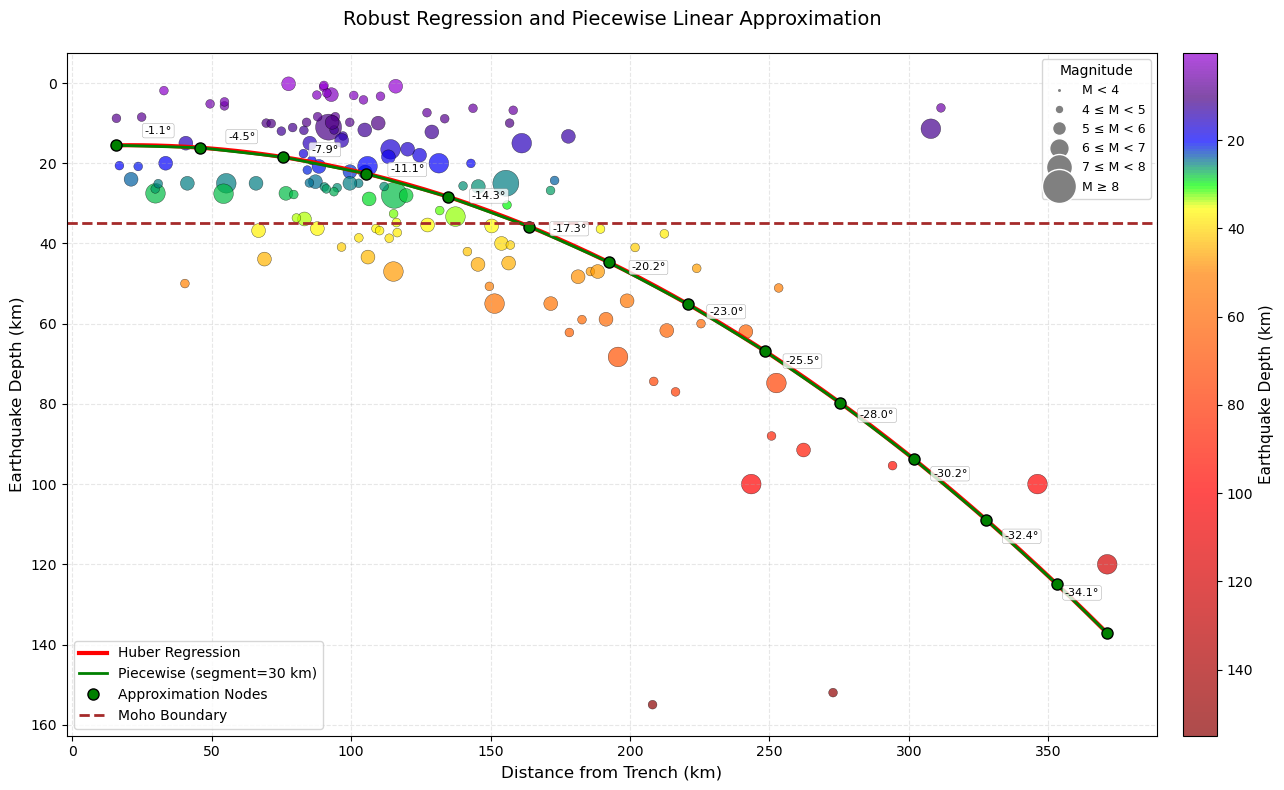

 Индекс Угол (градусы)
      0         -1.13°
      1         -4.52°
      2         -7.87°
      3        -11.14°
      4        -14.30°
      5        -17.33°
      6        -20.22°
      7        -22.96°
      8        -25.54°
      9        -27.97°
     10        -30.24°
     11        -32.37°
     12        -34.09°


In [159]:
# 1. Prepare smooth curve from regression
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
y_fit_scaled = model.predict(X_fit)  # Важно: подаем (N, 1), pipeline сам стандартизует и делает полином
y_fit = y_fit_scaled * y_std + y_mean

# 2. Flatten for piecewise approximation
X_appr = X_fit.flatten()
y_appr = y_fit.flatten()

# 3. Euclidean distance function
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# 4. Piecewise approximation function
def piecewise_approximation(X_appr, y_appr, segment_length):
    nodes = [(X_appr[0], y_appr[0])]
    total_distance = 0.0
    current_node = np.array(nodes[0])

    for i in range(1, len(X_appr)):
        next_point = np.array([X_appr[i], y_appr[i]])
        dist = euclidean_distance(current_node, next_point)

        while total_distance + dist >= segment_length:
            ratio = (segment_length - total_distance) / dist
            new_node = current_node + ratio * (next_point - current_node)
            nodes.append(tuple(new_node))
            current_node = new_node
            total_distance = 0.0
            dist = euclidean_distance(current_node, next_point)

        total_distance += dist
        current_node = next_point

    nodes.append((X_appr[-1], y_appr[-1]))

    hx, hy = zip(*nodes)
    angles = [np.arctan2(hy[i+1] - hy[i], hx[i+1] - hx[i]) for i in range(len(hx)-1)]
    return hx, hy, angles

# 5. Apply piecewise approximation
hx, hy, angles = piecewise_approximation(X_appr, y_appr, segment_length)

# 6. Visualization
plt.figure(figsize=(14, 8))

sizes = depth_distance_df_cleaned.loc[crustal_mask, 'mag'].apply(mag_to_size)

# Scatter plot
scatter = plt.scatter(
    X_filtered.flatten(),
    -y_filtered,
    c=-y_filtered,
    cmap=cmap_depth,
    s=sizes,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# Regression line
plt.plot(X_fit.flatten(), -y_fit, color='red', linewidth=3, label='Huber Regression')

# Piecewise approximation
plt.plot(hx, -np.array(hy), 'g-', linewidth=2, label=f'Piecewise (segment={segment_length} km)')
plt.plot(hx, -np.array(hy), 'go', markersize=8, markeredgecolor='black', markeredgewidth=1, label='Approximation Nodes')

# Annotate angles
for i in range(len(hx)-1):
    mid_x = (hx[i] + hx[i+1]) / 2
    mid_y = (hy[i] + hy[i+1]) / 2
    offset_y = 2  # text offset
    angle_deg = np.degrees(angles[i])
    plt.annotate(
        f'{angle_deg:.1f}°',
        xy=(mid_x, -(mid_y + offset_y)),
        xytext=(0, 2),
        textcoords='offset points',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.3),
        ha='center',
        va='bottom'
    )

# Moho boundary
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')

# Styling
ax = plt.gca()
ax.invert_yaxis()
plt.xlabel('Distance from Trench (km)', fontsize=12)
plt.ylabel('Earthquake Depth (km)', fontsize=12)
plt.title('Robust Regression and Piecewise Linear Approximation', fontsize=14, pad=20)
plt.grid(alpha=0.3, linestyle='--')

# Legend for magnitudes
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor='gray', markersize=np.sqrt(mag_to_size(mag)))
    for label, mag in legend_labels
]
first_legend = plt.legend(handles=legend_elements, title='Magnitude', loc='upper right', frameon=True, fontsize=9)
plt.gca().add_artist(first_legend)
plt.legend(loc='lower left', frameon=True, fontsize=10)

# Colorbar
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Earthquake Depth (km)', fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.savefig('plt/03_robust_approximation.jpg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 7. Print angles
df = pd.DataFrame({
    "Индекс": range(len(angles)),
    "Угол (градусы)": [f"{np.degrees(angle):.2f}°" for angle in angles]
})
print(df.to_string(index=False))
df.to_excel("Chignik Robust Regression.xlsx", index=False, sheet_name="Углы")


## Построение полиномиальной OLS регрессии второго порядка

OLS коэффициенты: [-0.56641279 -0.09121291]
OLS intercept: 0.09121291206923378


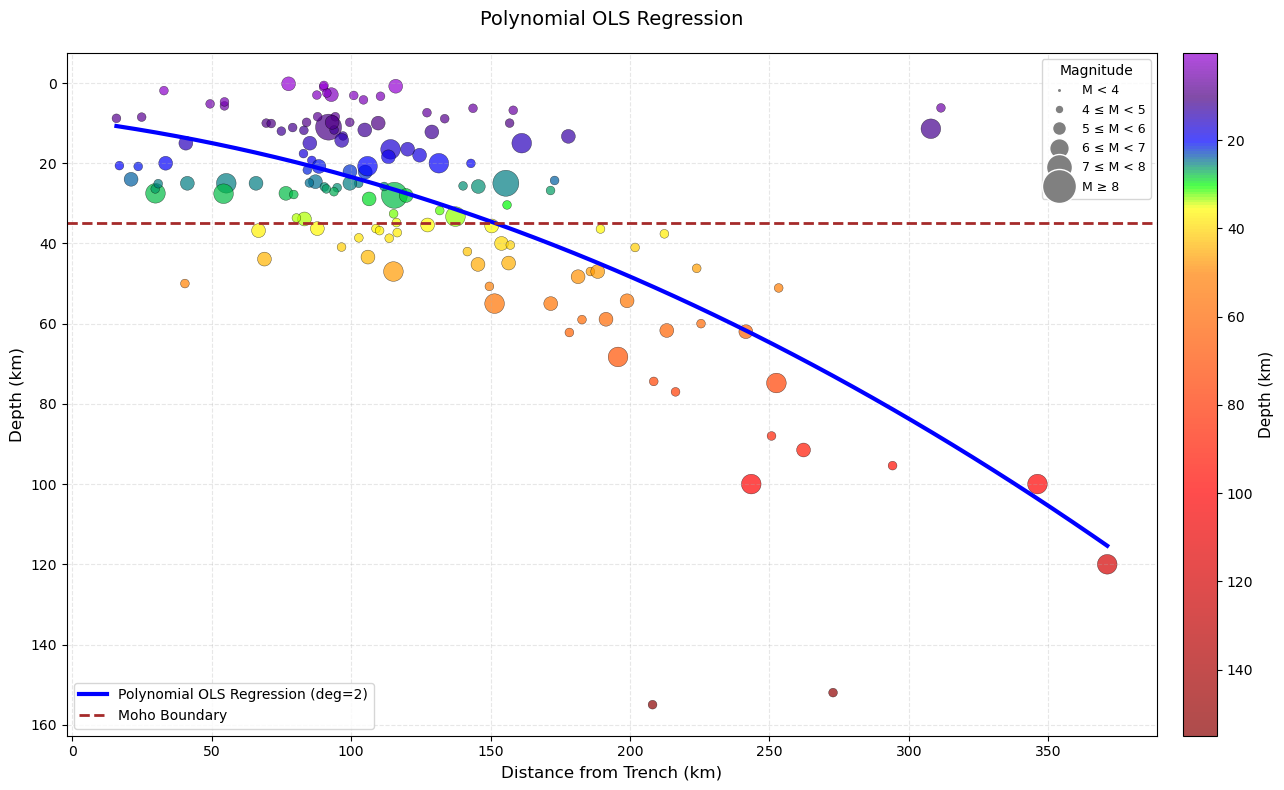

In [160]:
# 3. Standardize (reuse from previous if needed)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
mu_X, sigma_X = scaler.mean_[0], scaler.scale_[0]
y_mean, y_std = y_filtered.mean(), y_filtered.std()
y_scaled = (y_filtered - y_mean) / y_std

# 4. Polynomial transform

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 5. Classical Polynomial OLS Regression (degree 2)

from sklearn.linear_model import LinearRegression
ols_model = LinearRegression()
ols_model.fit(X_poly, y_scaled)
print("OLS коэффициенты:", ols_model.coef_)
print("OLS intercept:", ols_model.intercept_)

# 6. Predict on smooth linspace

X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 200).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = ols_model.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean

# 9. Plot comparison in the same style as previous plots

plt.figure(figsize=(14, 8))

# Fixed sizes for all filtered data (avoid mask mismatch)
sizes = depth_distance_df_cleaned['mag'].apply(mag_to_size)

scatter = plt.scatter(
    X_filtered.flatten(),
    -y_filtered,
    c=-y_filtered,
    cmap=cmap_depth,
    s=sizes,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
)
plt.plot(X_fit.flatten(), -y_fit, color='blue', linewidth=3, label='Polynomial OLS Regression (deg=2)')
plt.gca().invert_yaxis()
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')
plt.title('Polynomial OLS Regression', fontsize=14, pad=20)
plt.xlabel('Distance from Trench (km)', fontsize=12)
plt.ylabel('Depth (km)', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Depth (km)', fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.ax.invert_yaxis()

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor='gray', markersize=np.sqrt(mag_to_size(mag)))
    for label, mag in legend_labels
]
first_legend = plt.legend(handles=legend_elements, title='Magnitude', loc='upper right', frameon=True, fontsize=9)
plt.gca().add_artist(first_legend)
plt.legend(loc='lower left', frameon=True, fontsize=10)

plt.tight_layout()

plt.savefig('plt/04_OLS.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

## Кусочно-линейная аппроксимация полиномиальной OLS регрессии с расчетом углов наклона

Размеры: X_filtered=143, y_filtered=143, sizes=143


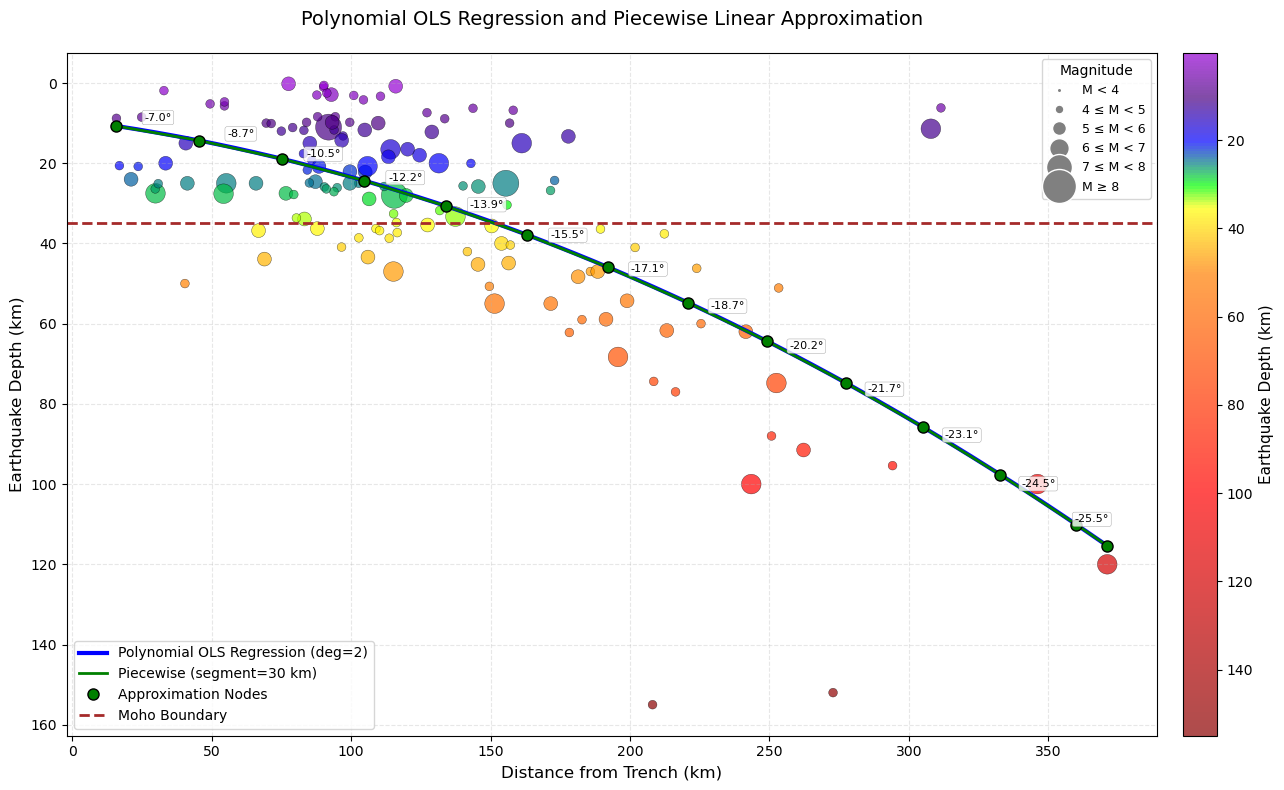

 Индекс Угол (градусы)
      0         -6.95°
      1         -8.73°
      2        -10.47°
      3        -12.19°
      4        -13.87°
      5        -15.52°
      6        -17.13°
      7        -18.70°
      8        -20.23°
      9        -21.71°
     10        -23.15°
     11        -24.54°
     12        -25.50°


In [161]:
# Подготовка кривой регрессии (использует уже отфильтрованные X_filtered/y_filtered)
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = ols_model.predict(X_fit_poly)  # Используем ols_model
y_fit = y_fit_scaled * y_std + y_mean

# Piecewise approximation (на оригинальной шкале)
X_appr = X_fit.flatten()
y_appr = y_fit.flatten()

# Функция евклидова расстояния
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# Функция кусочно-линейной аппроксимации
def piecewise_approximation(X_appr, y_appr, segment_length):
    nodes = [(X_appr[0], y_appr[0])]
    total_distance = 0.0
    current_node = np.array(nodes[0])

    for i in range(1, len(X_appr)):
        next_point = np.array([X_appr[i], y_appr[i]])
        dist = euclidean_distance(current_node, next_point)

        while total_distance + dist >= segment_length:
            ratio = (segment_length - total_distance) / dist
            new_node = current_node + ratio * (next_point - current_node)
            nodes.append(tuple(new_node))
            current_node = new_node
            total_distance = 0.0
            dist = euclidean_distance(current_node, next_point)

        total_distance += dist
        current_node = next_point

    nodes.append((X_appr[-1], y_appr[-1]))

    hx, hy = zip(*nodes)
    angles = [np.arctan2(hy[i+1] - hy[i], hx[i+1] - hx[i]) for i in range(len(hx)-1)]
    return hx, hy, angles

# Применяем аппроксимацию
hx, hy, angles = piecewise_approximation(X_appr, y_appr, segment_length)

# === Визуализация ===
plt.figure(figsize=(14, 8))

# Размеры точек: для ВСЕХ отфильтрованных данных (берем магнитуды из соответствующего датафрейма)
# Используем тот же датафрейм, что и для X_filtered и y_filtered
# Если X_filtered и y_filtered получены из depth_distance_df_cleaned, то используем его
sizes = depth_distance_df_cleaned['mag'].apply(mag_to_size)

# Проверяем размеры
print(f"Размеры: X_filtered={len(X_filtered)}, y_filtered={len(y_filtered)}, sizes={len(sizes)}")

# Точечная диаграмма (отфильтрованные данные)
scatter = plt.scatter(
    X_filtered.flatten(), 
    -y_filtered,
    c=-y_filtered,
    cmap=cmap_depth,
    s=sizes,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# Линия регрессии
plt.plot(X_fit.flatten(), -y_fit, color='blue', linewidth=3, label='Polynomial OLS Regression (deg=2)')

# Кусочно-линейная аппроксимация
plt.plot(hx, -np.array(hy), 'g-', linewidth=2, label=f'Piecewise (segment={segment_length} km)')
plt.plot(hx, -np.array(hy), 'go', markersize=8, markeredgecolor='black', markeredgewidth=1, label='Approximation Nodes')

# Отображение углов
for i in range(len(hx)-1):
    mid_x = (hx[i] + hx[i+1]) / 2
    mid_y = (hy[i] + hy[i+1]) / 2
    offset_y = 2
    angle_deg = np.degrees(angles[i])
    plt.annotate(f'{angle_deg:.1f}°', 
                xy=(mid_x, -(mid_y + offset_y)), 
                xytext=(0, 2), 
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.3),
                ha='center', va='bottom')

# Moho boundary
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')

# Стилизация
ax = plt.gca()
ax.invert_yaxis()
plt.xlabel('Distance from Trench (km)', fontsize=12)
plt.ylabel('Earthquake Depth (km)', fontsize=12)
plt.title('Polynomial OLS Regression and Piecewise Linear Approximation', fontsize=14, pad=20)
plt.grid(alpha=0.3, linestyle='--')

# Легенда для magnitude
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor='gray', markersize=np.sqrt(mag_to_size(mag)))
    for label, mag in legend_labels
]
first_legend = plt.legend(handles=legend_elements, title='Magnitude', loc='upper right', frameon=True, fontsize=9)
plt.gca().add_artist(first_legend)
plt.legend(loc='lower left', frameon=True, fontsize=10)

# Цветовая шкала
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Earthquake Depth (km)', fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.ax.invert_yaxis()

plt.tight_layout()

plt.savefig('plt/05_OLS_approximation.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# Печать углов
df = pd.DataFrame({
    "Индекс": range(len(angles)),
    "Угол (градусы)": [f"{np.degrees(angle):.2f}°" for angle in angles]
})

print(df.to_string(index=False))

output_file = "Chignik OLS.xlsx"
df.to_excel(output_file, index=False, sheet_name="Углы")
